# Afluencia diaria de Metrobús CDMX

# EDA: Afluencia del Metrobús CDMX (2005-2026)

## Objetivo
Analizar la evolución histórica de la afluencia diaria del Sistema de Transporte 
Metrobús de la Ciudad de México, identificando patrones de uso (estacionalidad 
semanal, crecimiento de la red), el impacto de la pandemia COVID-19, y diferencias 
de comportamiento entre líneas.

## Fuente de datos
Portal de Datos Abiertos de la CDMX — Afluencia Diaria de Metrobús CDMX (Simple).
https://datos.cdmx.gob.mx/dataset/afluencia-diaria-de-metrobus-cdmx

- **Periodo:** julio 2005 - julio 2026
- **Registros:** ~53,700 (formato largo: fecha × línea)
- **Actualización:** mensual por la Agencia Digital de Innovación Pública

## Herramientas
Python · pandas · matplotlib · seaborn

## Estructura del análisis
1. Carga y exploración inicial
2. Limpieza (nulos estructurales, normalización de categorías, outliers)
3. Análisis univariado
4. Análisis temporal (tendencia, estacionalidad, efecto COVID)
5. Análisis comparativo por línea
6. Resumen de calidad de datos
7. Conclusiones

In [7]:
from pathlib import Path
import pandas as pd

ruta_csv = Path.cwd().parent / "afluenciamb_simple_07_2026.csv"
df_afluencia = pd.read_csv(ruta_csv)

df_afluencia.head()

,fecha,anio,mes,linea,afluencia
0,2005-07-26,2005,Julio,Línea 1,3032667.0
1,2005-07-26,2005,Julio,Línea 5,NaN
2,2005-07-26,2005,Julio,Línea 2,NaN
3,2005-07-26,2005,Julio,Línea 3,NaN
4,2005-07-26,2005,Julio,Línea 6,NaN


In [10]:
print(df_afluencia.shape)
print(df_afluencia.columns.tolist())


(53732, 5)
['fecha', 'anio', 'mes', 'linea', 'afluencia']


In [11]:
df_afluencia.info()

<class 'pandas.DataFrame'>
RangeIndex: 53732 entries, 0 to 53731
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      53732 non-null  str    
 1   anio       53732 non-null  int64  
 2   mes        53732 non-null  str    
 3   linea      53732 non-null  str    
 4   afluencia  36505 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.0 MB


In [12]:
# 1. Tipos únicos y rango de columnas categóricas
print("Líneas únicas:", df_afluencia['linea'].unique())
print("\nMeses únicos:", df_afluencia['mes'].unique())
print("\nAños únicos:", sorted(df_afluencia['anio'].unique()))

Líneas únicas: <StringArray>
['Línea 1', 'Línea 5', 'Línea 2', 'Línea 3', 'Línea 6', 'Línea 7', 'Línea 4',
 'linea 1', 'linea 2', 'linea 3', 'linea 4', 'linea 5', 'linea 6', 'linea 7']
Length: 14, dtype: str

Meses únicos: <StringArray>
[     'Julio',     'Agosto', 'Septiembre',    'Octubre',  'Noviembre',
  'Diciembre',      'Enero',    'Febrero',      'Marzo',      'Abril',
       'Mayo',      'Junio']
Length: 12, dtype: str

Años únicos: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [13]:
# 2. Duplicados
print("Filas duplicadas:", df_afluencia.duplicated().sum())

Filas duplicadas: 0


In [14]:
# 3. Los nulos, desglosados por línea — esto es clave
nulos_por_linea = df_afluencia[df_afluencia['afluencia'].isna()].groupby('linea').size().sort_values(ascending=False)
print(nulos_por_linea)

linea
Línea 7    4663
Línea 6    3833
Línea 5    3025
Línea 4    2442
Línea 3    2024
Línea 2    1240
dtype: int64


In [15]:
# 4. Los nulos, desglosados por año — para ver si son líneas nuevas sin datos históricos
nulos_por_anio = df_afluencia[df_afluencia['afluencia'].isna()].groupby('anio').size().sort_values(ascending=False)
print(nulos_por_anio)

anio
2006    2190
2007    2190
2008    2181
2009    1825
2010    1825
2011    1499
2012    1190
2013    1039
2005     954
2014     730
2015     730
2016     388
2017     365
2018     121
dtype: int64


In [16]:
# 4. Los nulos, desglosados por año — para ver si son líneas nuevas sin datos históricos
nulos_por_anio = df_afluencia[df_afluencia['afluencia'].isna()].groupby('anio').size().sort_values(ascending=False)
print(nulos_por_anio)

anio
2006    2190
2007    2190
2008    2181
2009    1825
2010    1825
2011    1499
2012    1190
2013    1039
2005     954
2014     730
2015     730
2016     388
2017     365
2018     121
dtype: int64


entre más reciente el año, menos líneas faltan por abrir, por lo tanto menos nulos.

In [17]:
nulos_por_linea = df_afluencia[df_afluencia['afluencia'].isna()].groupby('linea').size().sort_values(ascending=False)
print(nulos_por_linea)

linea
Línea 7    4663
Línea 6    3833
Línea 5    3025
Línea 4    2442
Línea 3    2024
Línea 2    1240
dtype: int64


In [18]:
print("Líneas únicas:", df_afluencia['linea'].unique())

Líneas únicas: <StringArray>
['Línea 1', 'Línea 5', 'Línea 2', 'Línea 3', 'Línea 6', 'Línea 7', 'Línea 4',
 'linea 1', 'linea 2', 'linea 3', 'linea 4', 'linea 5', 'linea 6', 'linea 7']
Length: 14, dtype: str


# Limpieza


In [20]:
import re

# 1. Extraer el número de línea con regex (ignora tildes, mayúsculas, espacios extra)
df_afluencia['linea_num'] = df_afluencia['linea'].str.extract(r'(\d+)').astype(int)

# 2. Reconstruir la etiqueta limpia y consistente
df_afluencia['linea'] = 'Línea ' + df_afluencia['linea_num'].astype(str)

# 3. Verificamos: ahora deben ser exactamente 7 categorías
print(df_afluencia['linea'].unique())
print(df_afluencia['linea'].nunique())

<StringArray>
['Línea 1', 'Línea 5', 'Línea 2', 'Línea 3', 'Línea 6', 'Línea 7', 'Línea 4']
Length: 7, dtype: str
7


In [21]:
# 2. Convertir fecha a datetime
df_afluencia['fecha'] = pd.to_datetime(df_afluencia['fecha'], errors='coerce')

# ¿Alguna fecha no se pudo convertir?
print("Fechas inválidas:", df_afluencia['fecha'].isna().sum())

Fechas inválidas: 0


In [22]:
# 3. Revisar la columna 'mes' — confirmar si es texto o número, y si coincide con la fecha
print(df_afluencia['mes'].unique())

<StringArray>
[     'Julio',     'Agosto', 'Septiembre',    'Octubre',  'Noviembre',
  'Diciembre',      'Enero',    'Febrero',      'Marzo',      'Abril',
       'Mayo',      'Junio']
Length: 12, dtype: str


In [24]:
# 4. Re-verificar nulos por línea, YA con la columna normalizada
nulos_por_linea = df_afluencia[df_afluencia['afluencia'].isna()].groupby('linea').size().sort_values(ascending=False)
print(nulos_por_linea)

linea
Línea 7    4663
Línea 6    3833
Línea 5    3025
Línea 4    2442
Línea 3    2024
Línea 2    1240
dtype: int64


In [25]:
# Fecha mínima con dato real (no nulo) por línea
primer_dato_por_linea = df_afluencia[df_afluencia['afluencia'].notna()].groupby('linea')['fecha'].min().sort_values()
print(primer_dato_por_linea)

linea
Línea 1   2005-07-26
Línea 2   2008-12-17
Línea 3   2011-02-09
Línea 4   2012-04-02
Línea 5   2013-11-06
Línea 6   2016-01-23
Línea 7   2018-05-02
Name: fecha, dtype: datetime64[us]


In [26]:
# Confirmación: para cada línea, ¿TODOS los nulos ocurren ANTES de esa fecha de apertura?
for linea in df_afluencia['linea'].unique():
    apertura = primer_dato_por_linea[linea]
    nulos_despues_de_apertura = df_afluencia[
        (df_afluencia['linea'] == linea) &
        (df_afluencia['fecha'] >= apertura) &
        (df_afluencia['afluencia'].isna())
    ]
    print(f"{linea}: apertura {apertura.date()}, nulos DESPUÉS de apertura = {len(nulos_despues_de_apertura)}")

Línea 1: apertura 2005-07-26, nulos DESPUÉS de apertura = 0
Línea 5: apertura 2013-11-06, nulos DESPUÉS de apertura = 0
Línea 2: apertura 2008-12-17, nulos DESPUÉS de apertura = 0
Línea 3: apertura 2011-02-09, nulos DESPUÉS de apertura = 0
Línea 6: apertura 2016-01-23, nulos DESPUÉS de apertura = 0
Línea 7: apertura 2018-05-02, nulos DESPUÉS de apertura = 0
Línea 4: apertura 2012-04-02, nulos DESPUÉS de apertura = 0


dato bonito para incluir en tu storytelling final, porque no solo "limpiaste nulos", sino que descubriste y verificaste con evidencia el patrón de expansión de la red.

In [27]:
# Diccionario de apertura por línea (ya lo confirmamos con datos)
apertura_por_linea = primer_dato_por_linea.to_dict()

# Filtramos: nos quedamos solo con filas donde fecha >= apertura de esa línea
df_limpio = df_afluencia[
    df_afluencia.apply(lambda row: row['fecha'] >= apertura_por_linea[row['linea']], axis=1)
].copy()

print("Filas antes:", len(df_afluencia))
print("Filas después del filtro:", len(df_limpio))
print("Nulos restantes en afluencia:", df_limpio['afluencia'].isna().sum())

Filas antes: 53732
Filas después del filtro: 36505
Nulos restantes en afluencia: 0


In [28]:
# Verificación final: rango de fechas por línea en el dataset limpio
df_limpio.groupby('linea')['fecha'].agg(['min', 'max', 'count'])

,min,max,count
linea,,,
Línea 1,2005-07-26,2026-07-31,7676
Línea 2,2008-12-17,2026-07-31,6436
Línea 3,2011-02-09,2026-07-31,5652
Línea 4,2012-04-02,2026-07-31,5234
Línea 5,2013-11-06,2026-07-31,4651
Línea 6,2016-01-23,2026-07-31,3843
Línea 7,2018-05-02,2026-07-31,3013


In [29]:
# Guardamos un checkpoint del dataset limpio (buena práctica antes de seguir)
df_limpio.to_csv('metrobus_limpio.csv', index=False)

# Análisis univariado (afluencia total)

In [30]:
# 1. Estadísticas descriptivas generales
df_limpio['afluencia'].describe()

count    3.650500e+04
mean     1.673270e+05
std      1.173459e+05
min      9.000000e+00
25%      8.394700e+04
50%      1.370900e+05
75%      2.065970e+05
max      3.032667e+06
Name: afluencia, dtype: float64

In [31]:
# 2. Lo mismo pero por línea, para comparar escalas
df_limpio.groupby('linea')['afluencia'].describe()

,count,mean,std,min,25%,50%,75%,max
linea,,,,,,,,
Línea 1,7676.0,326326.961699,138445.400346,28080.0,225612.25,322868.0,445081.50,3032667.0
Línea 2,6436.0,146197.625544,56191.228195,9.0,103509.75,148312.0,187711.50,305080.0
Línea 3,5652.0,133332.055556,43908.932384,20463.0,101586.25,133742.0,172025.75,239174.0
Línea 4,5234.0,64807.669372,26969.931781,2748.0,45945.25,63736.5,79955.75,125793.0
Línea 5,4651.0,132992.337992,81953.047097,18711.0,69125.00,96766.0,197863.50,322550.0
Línea 6,3843.0,158931.278428,54363.418447,22550.0,109747.00,166052.0,207266.50,264311.0
Línea 7,3013.0,112957.885164,39990.278187,12559.0,79697.00,121382.0,142894.00,209011.0


In [33]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 8.6 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.5 MB 9.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 9.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.2 MB 3.8 MB/s eta 0:00:02
   ---------- ----------------------------- 1.8/7.2 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.4/7.2 MB 5.2 MB/s eta 0:00:01
   --------------------- ------------------ 3.9/7.2 MB 4.9 MB/s eta 0:00:01
   ------------------------ ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


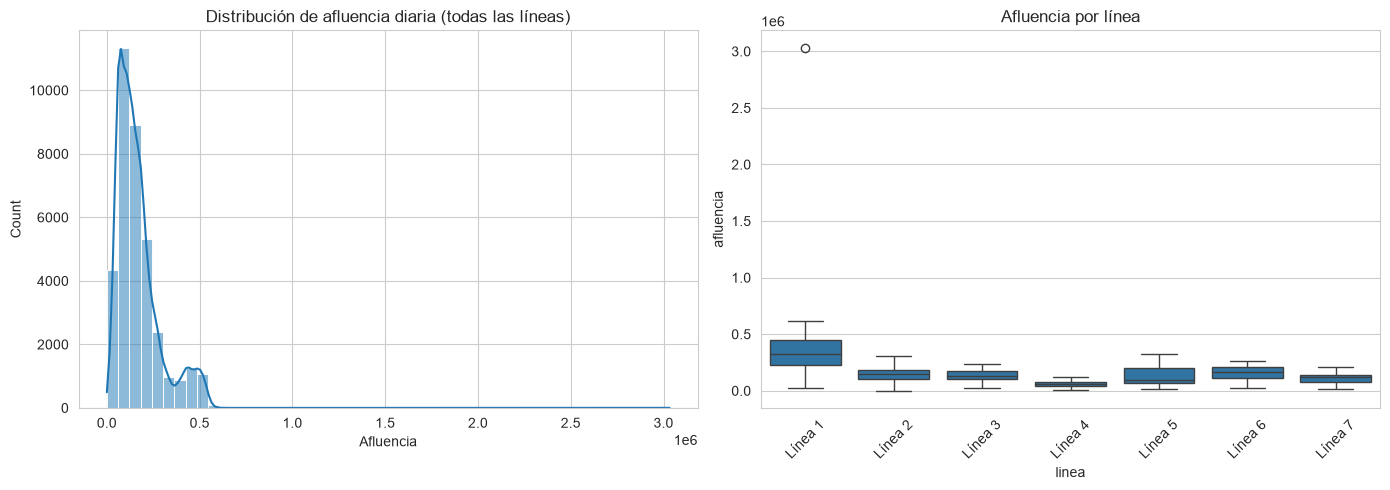

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la afluencia total (todas las líneas juntas)
sns.histplot(df_limpio['afluencia'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribución de afluencia diaria (todas las líneas)')
axes[0].set_xlabel('Afluencia')

# Boxplot por línea — para comparar distribución y detectar outliers
sns.boxplot(data=df_limpio, x='linea', y='afluencia', order=sorted(df_limpio['linea'].unique()), ax=axes[1])
axes[1].set_title('Afluencia por línea')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

-histograma está fuertemente sesgado a la derecha
-Hay un outlier extremo en Línea 1

In [37]:
# Top 5 valores más altos de afluencia en todo el dataset
df_limpio.nlargest(5, 'afluencia')[['fecha', 'linea', 'afluencia']]

,fecha,linea,afluencia
0,2005-07-26,Línea 1,3032667.0
52549,2026-02-13,Línea 1,619643.0
27212,2016-03-17,Línea 1,615838.0
34033,2018-11-16,Línea 1,590881.0
36576,2019-11-15,Línea 1,589276.0


In [38]:
# Contexto: valores de Línea 1 alrededor de esa fecha sospechosa (+/- 5 días)
fecha_sospechosa = df_limpio.nlargest(1, 'afluencia')['fecha'].values[0]
ventana = df_limpio[
    (df_limpio['linea'] == 'Línea 1') &
    (df_limpio['fecha'] >= pd.Timestamp(fecha_sospechosa) - pd.Timedelta(days=5)) &
    (df_limpio['fecha'] <= pd.Timestamp(fecha_sospechosa) + pd.Timedelta(days=5))
]
print(ventana[['fecha', 'afluencia']])

        fecha  afluencia
0  2005-07-26  3032667.0
7  2005-07-27   230465.0
17 2005-07-28   237296.0
23 2005-07-29   258356.0
29 2005-07-30   159470.0
39 2005-07-31   104834.0


In [40]:
# Guardamos el índice del valor sospechoso, para dejar rastro de qué se modificó
idx_outlier = df_limpio[(df_limpio['fecha'] == '2005-07-26') & (df_limpio['linea'] == 'Línea 1')].index

# Creamos una columna flag ANTES de tocar el dato — buena práctica para trazabilidad
df_limpio['outlier_flag'] = False
df_limpio.loc[idx_outlier, 'outlier_flag'] = True

# Guardamos el valor original por si se necesita consultar después
df_limpio['afluencia_original'] = df_limpio['afluencia']

# Lo tratamos como NaN (dato erróneo) en vez de borrarlo — más transparente para el análisis
df_limpio.loc[idx_outlier, 'afluencia'] = None

print(df_limpio[df_limpio['outlier_flag']][['fecha','linea','afluencia_original','afluencia']])

       fecha    linea  afluencia_original  afluencia
0 2005-07-26  Línea 1           3032667.0        NaN


In [42]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 36505 entries, 0 to 53731
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               36505 non-null  datetime64[us]
 1   anio                36505 non-null  int64         
 2   mes                 36505 non-null  str           
 3   linea               36505 non-null  str           
 4   afluencia           36504 non-null  float64       
 5   linea_num           36505 non-null  int64         
 6   outlier_flag        36505 non-null  bool          
 7   afluencia_original  36505 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 3.3 MB


# Tratamiento del outlier

In [43]:
# Guardamos el índice del valor sospechoso, para dejar rastro de qué se modificó
idx_outlier = df_limpio[(df_limpio['fecha'] == '2005-07-26') & (df_limpio['linea'] == 'Línea 1')].index

# Creamos una columna flag ANTES de tocar el dato — buena práctica para trazabilidad
df_limpio['outlier_flag'] = False
df_limpio.loc[idx_outlier, 'outlier_flag'] = True

# Guardamos el valor original por si se necesita consultar después
df_limpio['afluencia_original'] = df_limpio['afluencia']

# Lo tratamos como NaN (dato erróneo) en vez de borrarlo — más transparente para el análisis
df_limpio.loc[idx_outlier, 'afluencia'] = None

print(df_limpio[df_limpio['outlier_flag']][['fecha','linea','afluencia_original','afluencia']])

       fecha    linea  afluencia_original  afluencia
0 2005-07-26  Línea 1                 NaN        NaN


In [45]:
# Calculamos Q1, Q3, IQR por línea usando transform (evita el problema de apply)
q1 = df_limpio.groupby('linea')['afluencia'].transform(lambda x: x.quantile(0.25))
q3 = df_limpio.groupby('linea')['afluencia'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

# Filtramos directamente sobre el dataframe original — sin apply, sin perder columnas
outliers_totales = df_limpio[
    (df_limpio['afluencia'] < limite_inf) | (df_limpio['afluencia'] > limite_sup)
]

print("Total de outliers detectados (IQR):", len(outliers_totales))
outliers_totales.groupby('linea').size().sort_values(ascending=False)

Total de outliers detectados (IQR): 0


Series([], dtype: int64)

# Comprobación de valores anomalos


In [48]:
# Sanity check: límites calculados para Línea 1 (la que sabíamos tenía el outlier)
linea1 = df_limpio[df_limpio['linea'] == 'Línea 1']
q1 = linea1['afluencia'].quantile(0.25)
q3 = linea1['afluencia'].quantile(0.75)
iqr = q3 - q1
print(f"Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}")
print(f"Límite inferior: {q1 - 1.5*iqr:.0f}")
print(f"Límite superior: {q3 + 1.5*iqr:.0f}")
print(f"Máximo real en Línea 1: {linea1['afluencia'].max():.0f}")

Q1=225602, Q3=445068, IQR=219466
Límite inferior: -103596
Límite superior: 774268
Máximo real en Línea 1: 619643


# Paso 5: Análisis temporal

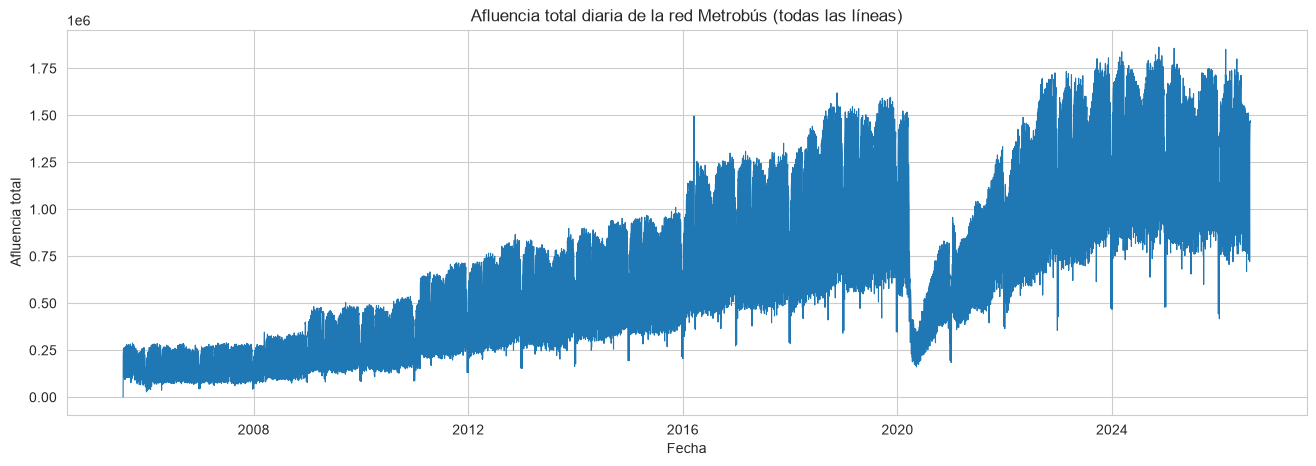

In [49]:
# 1. Serie agregada: afluencia TOTAL de la red por día (sumando las 7 líneas)
afluencia_diaria_total = df_limpio.groupby('fecha')['afluencia'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(afluencia_diaria_total['fecha'], afluencia_diaria_total['afluencia'], linewidth=0.8)
plt.title('Afluencia total diaria de la red Metrobús (todas las líneas)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.show()

# A) Suavizado con media movil

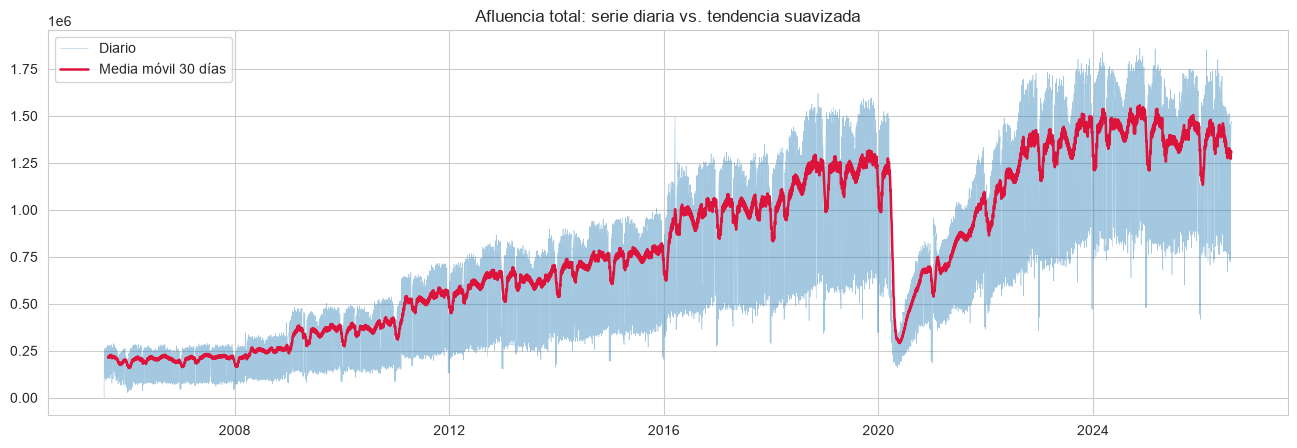

In [53]:
afluencia_diaria_total = afluencia_diaria_total.sort_values('fecha')
afluencia_diaria_total['media_movil_30d'] = afluencia_diaria_total['afluencia'].rolling(window=30).mean()

plt.figure(figsize=(16, 5))
plt.plot(afluencia_diaria_total['fecha'], afluencia_diaria_total['afluencia'], linewidth=0.4, alpha=0.4, label='Diario')
plt.plot(afluencia_diaria_total['fecha'], afluencia_diaria_total['media_movil_30d'], linewidth=1.8, color='crimson', label='Media móvil 30 días')
plt.title('Afluencia total: serie diaria vs. tendencia suavizada')
plt.legend()
plt.show()

# B) Estacionalidad semanal

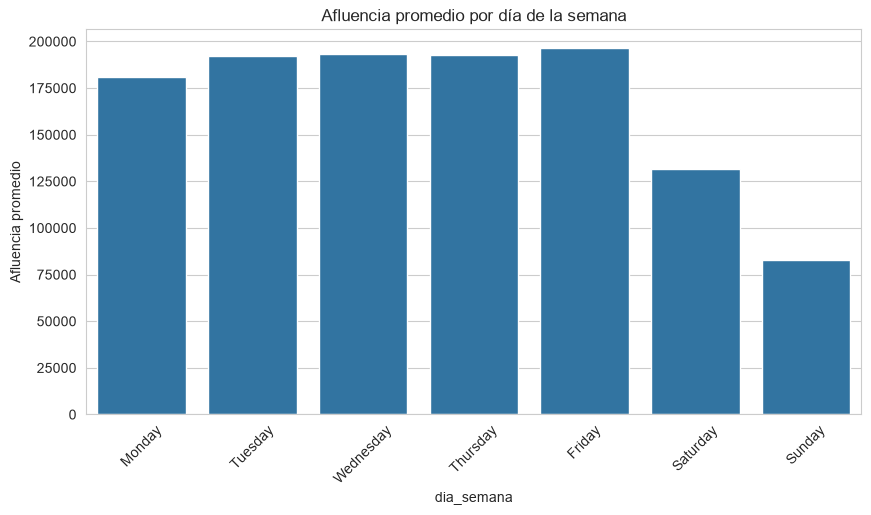

In [54]:
df_limpio['dia_semana'] = df_limpio['fecha'].dt.day_name()
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

afluencia_por_dia = df_limpio.groupby('dia_semana')['afluencia'].mean().reindex(orden_dias)

plt.figure(figsize=(10, 5))
sns.barplot(x=afluencia_por_dia.index, y=afluencia_por_dia.values)
plt.title('Afluencia promedio por día de la semana')
plt.ylabel('Afluencia promedio')
plt.xticks(rotation=45)
plt.show()

# C) Zoom al periodo COVID

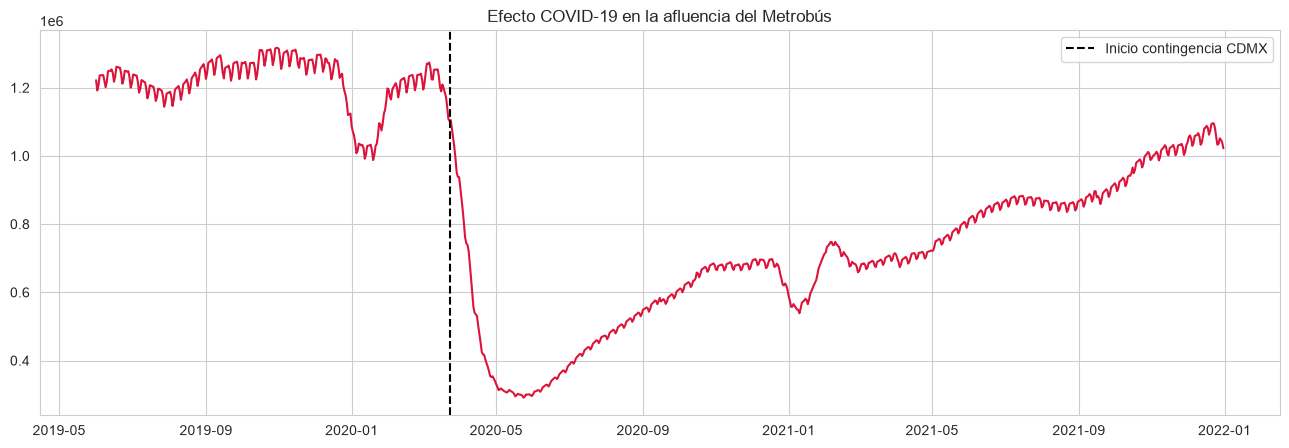

In [55]:
covid = afluencia_diaria_total[(afluencia_diaria_total['fecha'] >= '2019-06-01') & (afluencia_diaria_total['fecha'] <= '2021-12-31')]

plt.figure(figsize=(16, 5))
plt.plot(covid['fecha'], covid['media_movil_30d'], color='crimson')
plt.axvline(pd.Timestamp('2020-03-23'), color='black', linestyle='--', label='Inicio contingencia CDMX')
plt.title('Efecto COVID-19 en la afluencia del Metrobús')
plt.legend()
plt.show()

In [56]:
# 1. Magnitud de la caída COVID (usando la media móvil para evitar ruido)
pre_covid = afluencia_diaria_total[
    (afluencia_diaria_total['fecha'] >= '2020-01-01') & (afluencia_diaria_total['fecha'] <= '2020-03-15')
]['media_movil_30d'].mean()

minimo_covid = afluencia_diaria_total[
    (afluencia_diaria_total['fecha'] >= '2020-03-15') & (afluencia_diaria_total['fecha'] <= '2020-07-01')
]['media_movil_30d'].min()

caida_pct = (minimo_covid - pre_covid) / pre_covid * 100
print(f"Afluencia pre-COVID (promedio ene-mar 2020): {pre_covid:,.0f}")
print(f"Mínimo durante COVID: {minimo_covid:,.0f}")
print(f"Caída: {caida_pct:.1f}%")

Afluencia pre-COVID (promedio ene-mar 2020): 1,152,301
Mínimo durante COVID: 290,894
Caída: -74.8%


In [57]:
# 2. ¿Cuándo se recuperó al nivel pre-pandemia? (primera fecha en que la media móvil vuelve a igualar/superar pre_covid)
post_minimo = afluencia_diaria_total[afluencia_diaria_total['fecha'] > '2020-07-01']
recuperacion = post_minimo[post_minimo['media_movil_30d'] >= pre_covid]

if len(recuperacion) > 0:
    fecha_recuperacion = recuperacion.iloc[0]['fecha']
    meses_recuperacion = (fecha_recuperacion - pd.Timestamp('2020-03-15')).days / 30
    print(f"Fecha de recuperación al nivel pre-COVID: {fecha_recuperacion.date()}")
    print(f"Meses que tardó en recuperarse: {meses_recuperacion:.1f}")
else:
    print("Aún no se ha recuperado al nivel pre-COVID dentro del rango de datos")

Fecha de recuperación al nivel pre-COVID: 2022-04-07
Meses que tardó en recuperarse: 25.1


In [58]:
# 3. Ratio fin de semana vs. entre semana (para cuantificar lo que vimos en la gráfica 2)
entre_semana = afluencia_por_dia[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
sabado = afluencia_por_dia['Saturday']
domingo = afluencia_por_dia['Sunday']

print(f"Promedio entre semana: {entre_semana:,.0f}")
print(f"Sábado: {sabado:,.0f} ({(sabado/entre_semana - 1)*100:.1f}% vs entre semana)")
print(f"Domingo: {domingo:,.0f} ({(domingo/entre_semana - 1)*100:.1f}% vs entre semana)")

Promedio entre semana: 191,241
Sábado: 131,454 (-31.3% vs entre semana)
Domingo: 82,979 (-56.6% vs entre semana)


# Análisis comparativo por línea

a) Participación de cada línea en el total histórico

In [59]:
participacion = df_limpio.groupby('linea')['afluencia'].sum().sort_values(ascending=False)
participacion_pct = (participacion / participacion.sum() * 100).round(1)

resumen_lineas = pd.DataFrame({
    'afluencia_total': participacion,
    'participacion_%': participacion_pct
})
print(resumen_lineas)

         afluencia_total  participacion_%
linea                                    
Línea 1     2.501853e+09             41.0
Línea 2     9.409279e+08             15.4
Línea 3     7.535928e+08             12.3
Línea 5     6.185474e+08             10.1
Línea 6     6.107729e+08             10.0
Línea 7     3.403421e+08              5.6
Línea 4     3.392033e+08              5.6


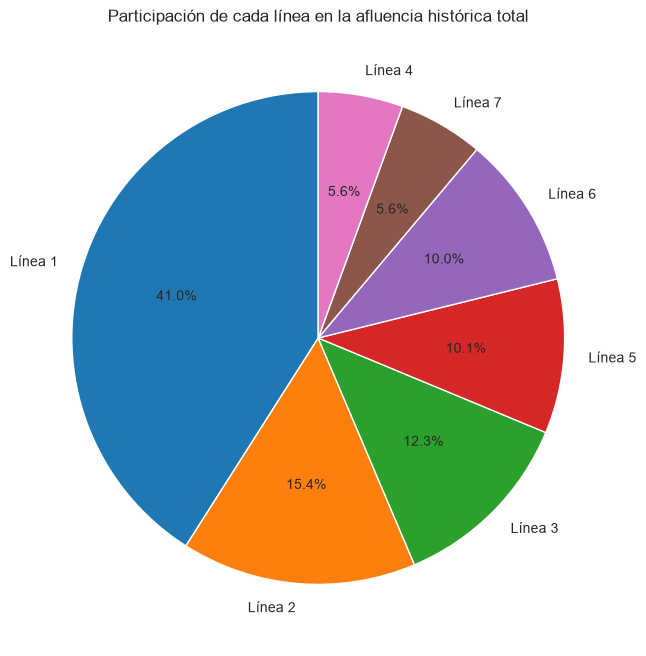

In [60]:
plt.figure(figsize=(8, 8))
plt.pie(participacion, labels=participacion.index, autopct='%1.1f%%', startangle=90)
plt.title('Participación de cada línea en la afluencia histórica total')
plt.show()

b) Evolución por línea a lo largo del tiempo

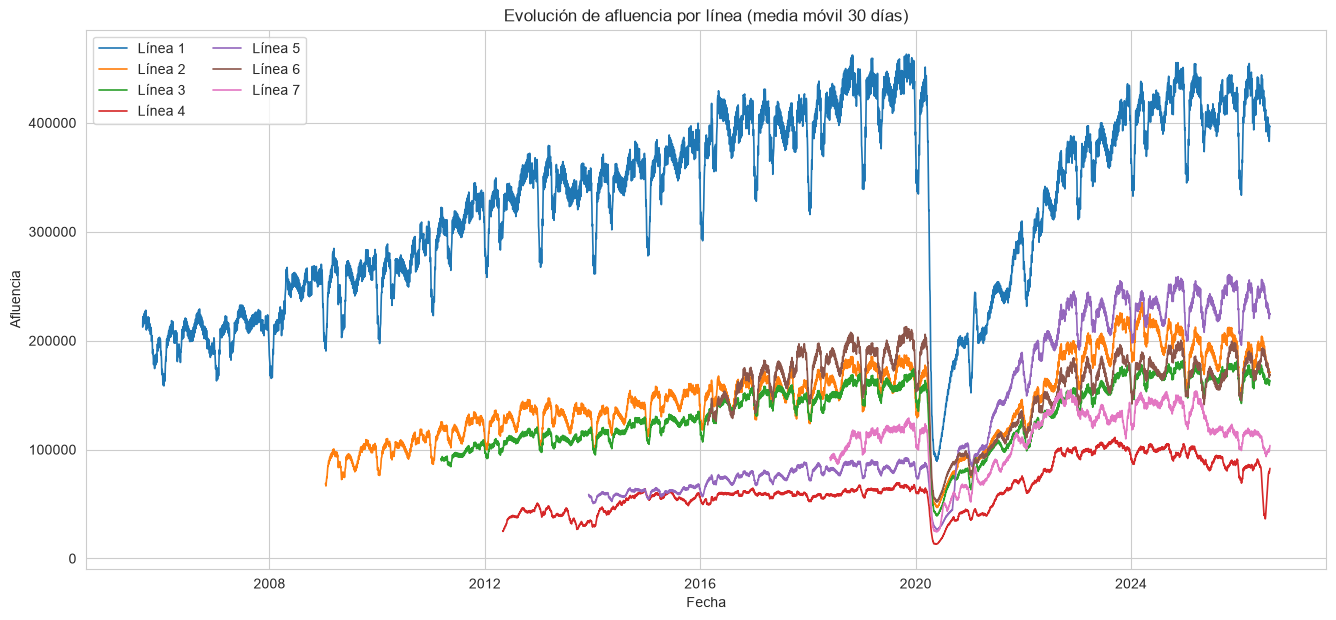

In [61]:
pivot_lineas = df_limpio.pivot_table(index='fecha', columns='linea', values='afluencia', aggfunc='sum')
pivot_suavizado = pivot_lineas.rolling(window=30).mean()

plt.figure(figsize=(16, 7))
for linea in sorted(pivot_suavizado.columns):
    plt.plot(pivot_suavizado.index, pivot_suavizado[linea], label=linea, linewidth=1.2)

plt.title('Evolución de afluencia por línea (media móvil 30 días)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia')
plt.legend(loc='upper left', ncol=2)
plt.show()

c) Recuperación post-COVID comparada por línea


In [62]:
resultados_recuperacion = []

for linea in sorted(df_limpio['linea'].unique()):
    serie_linea = pivot_suavizado[linea]
    
    pre = serie_linea[(serie_linea.index >= '2020-01-01') & (serie_linea.index <= '2020-03-15')].mean()
    minimo = serie_linea[(serie_linea.index >= '2020-03-15') & (serie_linea.index <= '2020-07-01')].min()
    actual = serie_linea[serie_linea.index >= serie_linea.index.max() - pd.Timedelta(days=90)].mean()
    
    caida_pct = (minimo - pre) / pre * 100
    recuperacion_actual_pct = (actual - pre) / pre * 100
    
    resultados_recuperacion.append({
        'linea': linea,
        'pre_covid': round(pre),
        'minimo_covid': round(minimo),
        'caida_%': round(caida_pct, 1),
        'nivel_actual': round(actual),
        'vs_pre_covid_%': round(recuperacion_actual_pct, 1)
    })

df_recuperacion = pd.DataFrame(resultados_recuperacion).sort_values('vs_pre_covid_%')
print(df_recuperacion)

     linea  pre_covid  minimo_covid  caida_%  nivel_actual  vs_pre_covid_%
6  Línea 7     113417         24387    -78.5        105258            -7.2
5  Línea 6     183179         51680    -71.8        180804            -1.3
0  Línea 1     402767         89237    -77.8        418323             3.9
3  Línea 4      62109         13146    -78.8         68743            10.7
2  Línea 3     151970         38952    -74.4        168712            11.0
1  Línea 2     157410         46726    -70.3        188946            20.0
4  Línea 5      81449         26619    -67.3        241403           196.4


In [63]:
# 1. Revisar fecha máxima real del dataset y cuántos días tiene el último mes
print("Fecha máxima en el dataset:", df_limpio['fecha'].max())

ultimo_mes = df_limpio[df_limpio['fecha'] >= df_limpio['fecha'].max() - pd.Timedelta(days=35)]
print(ultimo_mes.groupby('linea')['fecha'].agg(['min','max','count']))

Fecha máxima en el dataset: 2026-07-31 00:00:00
               min        max  count
linea                               
Línea 1 2026-06-26 2026-07-31     36
Línea 2 2026-06-26 2026-07-31     36
Línea 3 2026-06-26 2026-07-31     36
Línea 4 2026-06-26 2026-07-31     36
Línea 5 2026-06-26 2026-07-31     36
Línea 6 2026-06-26 2026-07-31     36
Línea 7 2026-06-26 2026-07-31     36


In [64]:
# 2. Investigar el caso Línea 5: ¿cuántos días tiene su ventana pre-covid?
linea5_pre = df_limpio[
    (df_limpio['linea'] == 'Línea 5') &
    (df_limpio['fecha'] >= '2020-01-01') & (df_limpio['fecha'] <= '2020-03-15')
]
print("Días con dato en ventana pre-COVID (Línea 5):", len(linea5_pre))
print(linea5_pre['afluencia'].describe())

Días con dato en ventana pre-COVID (Línea 5): 75
count        75.000000
mean      83152.573333
std       18522.096399
min       32193.000000
25%       69626.500000
50%       93818.000000
75%       96614.500000
max      105433.000000
Name: afluencia, dtype: float64


# Paso 7: Resumen de calidad de datos

-Línea 1 concentra 41% de la afluencia histórica total

-Todas las líneas cayeron entre -67% y -79% en COVID (caída bastante uniforme)


-La recuperación fue muy desigual: Línea 5 explotó (+196%), Línea 7 y 6 aún no recuperan su nivel pre-pandemia

-Posible efecto estacional de verano visible al cierre de la serie

In [65]:
resumen_calidad = f"""
RESUMEN DE CALIDAD DE DATOS - Afluencia Metrobús CDMX
========================================================
Registros originales: {len(df_afluencia):,}
Registros después de limpieza: {len(df_limpio):,}
Periodo cubierto: {df_limpio['fecha'].min().date()} a {df_limpio['fecha'].max().date()}

Hallazgos y tratamientos aplicados:
1. Nulos estructurales: {df_afluencia['afluencia'].isna().sum():,} filas con NaN en 'afluencia',
   causados por líneas que aún no habían abierto (no son datos faltantes reales).
   Tratamiento: filtrado de cada línea desde su fecha real de apertura.

2. Inconsistencia de categorías: la columna 'linea' tenía 14 variantes (mayúsculas/
   tildes inconsistentes) para 7 líneas reales. Tratamiento: normalización vía regex.

3. Outlier extremo: 1 registro (Línea 1, 2005-07-26) con valor de 3,032,667 
   (~13x el valor de días adyacentes), correspondiente al primer día de operación.
   Tratamiento: marcado con flag + valor original conservado, tratado como NaN
   para fines de análisis estadístico.

4. Verificación IQR: sin outliers adicionales tras el tratamiento anterior.
"""
print(resumen_calidad)


RESUMEN DE CALIDAD DE DATOS - Afluencia Metrobús CDMX
Registros originales: 53,732
Registros después de limpieza: 36,505
Periodo cubierto: 2005-07-26 a 2026-07-31

Hallazgos y tratamientos aplicados:
1. Nulos estructurales: 17,227 filas con NaN en 'afluencia',
   causados por líneas que aún no habían abierto (no son datos faltantes reales).
   Tratamiento: filtrado de cada línea desde su fecha real de apertura.

2. Inconsistencia de categorías: la columna 'linea' tenía 14 variantes (mayúsculas/
   tildes inconsistentes) para 7 líneas reales. Tratamiento: normalización vía regex.

3. Outlier extremo: 1 registro (Línea 1, 2005-07-26) con valor de 3,032,667 
   (~13x el valor de días adyacentes), correspondiente al primer día de operación.
   Tratamiento: marcado con flag + valor original conservado, tratado como NaN
   para fines de análisis estadístico.

4. Verificación IQR: sin outliers adicionales tras el tratamiento anterior.



## Conclusiones

Este EDA analiza la afluencia diaria del Metrobús CDMX de 2005 a 2026 (~53,700 registros, 
7 líneas), con el objetivo de caracterizar patrones de uso, el impacto de la pandemia y 
la evolución de la red.

### Hallazgos principales

**1. Expansión de la red y liderazgo de Línea 1**
La red creció de 1 a 7 líneas entre 2005 y 2018. Línea 1 concentra el 41% de la afluencia 
histórica total de la red — más que las 6 líneas restantes combinadas en varios periodos —, 
consistente con su rol como corredor troncal (Insurgentes).

**2. Patrón de uso predominantemente laboral**
La afluencia entre semana es estable (~191,000 pasajeros/día promedio), pero cae 31.3% 
los sábados y 56.6% los domingos. Este patrón confirma que el Metrobús se usa 
mayoritariamente para viajes de trabajo/escuela, no de forma recreativa.

**3. Impacto severo y prolongado de COVID-19**
La afluencia cayó 74.8% entre marzo y julio de 2020 (de 1,152,301 a 290,894 
pasajeros/día). La recuperación al nivel pre-pandemia tomó 25.1 meses, alcanzándose 
hasta abril de 2022.

**4. Recuperación desigual entre líneas**
Aunque la caída inicial fue relativamente uniforme entre líneas (-67% a -79%), la 
recuperación no lo fue: Línea 5 superó su nivel pre-COVID en +196%, mientras que 
Línea 7 (-7.2%) y Línea 6 (-1.3%) aún no recuperan sus niveles de 2020 — posible 
reflejo de cambios diferenciados en movilidad y trabajo híbrido según zona de cobertura.

**5. Calidad de datos**
Se identificaron y corrigieron 3 problemas de calidad: nulos estructurales por líneas 
aún no inauguradas (tratados mediante filtrado por fecha real de apertura, no 
imputación), inconsistencias de formato en categorías de línea (14 variantes → 7 
reales, vía regex), y un outlier extremo del primer día de operación (documentado 
y tratado sin perder trazabilidad).

### Posibles siguientes pasos
- Cruzar con datos de clima o eventos (huelgas, obras) para explicar caídas puntuales.
- Modelo de forecasting de demanda por línea (conecta con el proyecto de Regression).
- Segmentación de líneas por perfil de uso (clustering con features de estacionalidad,
  ratio fin de semana/entre semana, tasa de recuperación post-COVID).